In [487]:
import sys
import os
from dotenv import load_dotenv

current_dir = os.path.abspath('')
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

load_dotenv(os.path.join(parent_dir, '.env'))

True

In [488]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import optuna
import joblib
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sqlalchemy import text
from config import engine

In [489]:
def fetch() -> pd.DataFrame:
    query = """
        SELECT 
            dd.date AS order_date, 
            pr.is_muslim_fashion, oc.quantity
        FROM order_fact oc
        JOIN date_dimension dd ON dd.date_id = oc.date_id
        JOIN product_dimension pr ON pr.product_id = oc.product_id
        WHERE oc.status = 'SELESAI'
    """
    with engine.connect() as conn:
        df = pd.read_sql(text(query), conn)

    df["order_date"] = pd.to_datetime(df["order_date"])
    df = df[df["quantity"] > 0]
    df = df.groupby("order_date").agg({
        "quantity": "sum",
        "is_muslim_fashion": "max"
    }).reset_index()
    return df

In [490]:
df = fetch()

2026-06-02 23:36:06,862 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-02 23:36:06,871 INFO sqlalchemy.engine.Engine 
        SELECT 
            dd.date AS order_date, 
            pr.is_muslim_fashion, oc.quantity
        FROM order_fact oc
        JOIN date_dimension dd ON dd.date_id = oc.date_id
        JOIN product_dimension pr ON pr.product_id = oc.product_id
        WHERE oc.status = 'SELESAI'
    
2026-06-02 23:36:06,876 INFO sqlalchemy.engine.Engine [cached since 1457s ago] {}
2026-06-02 23:36:07,271 INFO sqlalchemy.engine.Engine ROLLBACK


In [491]:
query = """
    SELECT 
        date AS order_date, days_name, month, is_weekend, 
        is_twin_date, is_payday, is_ramadhan
    FROM date_dimension
    WHERE date BETWEEN '2024-01-01' AND '2026-12-31'
"""
with engine.connect() as conn:
    df_date_prop = pd.read_sql(text(query), conn)
    
df_date_prop["order_date"] = pd.to_datetime(df_date_prop["order_date"])   
        
all_dates = pd.date_range(df.order_date.min(), df.order_date.max(), freq="D")

df = df.set_index("order_date")
df = df.reindex(all_dates)
df = df.reset_index().rename(columns={"index": "order_date"})

df = df.merge(df_date_prop, on="order_date", how="left")
df = df.fillna({
    "quantity": 0,
    "is_muslim_fashion": 0,
})

2026-06-02 23:36:07,400 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-02 23:36:07,401 INFO sqlalchemy.engine.Engine 
    SELECT 
        date AS order_date, days_name, month, is_weekend, 
        is_twin_date, is_payday, is_ramadhan
    FROM date_dimension
    WHERE date BETWEEN '2024-01-01' AND '2026-12-31'

2026-06-02 23:36:07,402 INFO sqlalchemy.engine.Engine [cached since 1.252e+05s ago] {}
2026-06-02 23:36:07,447 INFO sqlalchemy.engine.Engine ROLLBACK


In [492]:
df["rolling_mean_7_qty"] = df["quantity"].rolling(window=7, min_periods=1, closed="left").mean()
df["rolling_mean_14_qty"] = df["quantity"].rolling(window=14, min_periods=1, closed="left").mean()
df["rolling_mean_30_qty"] = df["quantity"].rolling(window=30, min_periods=1, closed="left").mean()

df["rolling_std_3_qty"] = df["quantity"].rolling(window=3, min_periods=1, closed="left").std()
df["rolling_std_7_qty"] = df["quantity"].rolling(window=7, min_periods=1, closed="left").std()

df["lag_1_qty"] = df["quantity"].shift(1)
df["lag_3_qty"] = df["quantity"].shift(3)
df["lag_7_qty"] = df["quantity"].shift(7)
df["lag_21_qty"] = df["quantity"].shift(21)
df["lag_28_qty"] = df["quantity"].shift(28)

df["lag_7_rolling_mean"] = df["rolling_mean_7_qty"].shift(7)
df["lag_14_rolling_mean"] = df["rolling_mean_14_qty"].shift(14)

df = df.dropna().reset_index(drop=True)

In [493]:
df["payday_weekend"] = df["is_payday"] * df["is_weekend"]
df["ramadhan_twin"] = df["is_ramadhan"] * df["is_twin_date"]
df["day_of_year"] = df["order_date"].dt.dayofyear
df["week_of_year"] = df["order_date"].dt.isocalendar().week.astype(int)

df["is_month_end"] = df["order_date"].dt.is_month_end.astype(int)
df["is_month_start"] = df["order_date"].dt.is_month_start.astype(int)


In [494]:
cat_cols = ["days_name", "month"]

for col in cat_cols:
    df[col] = df[col].astype("category")

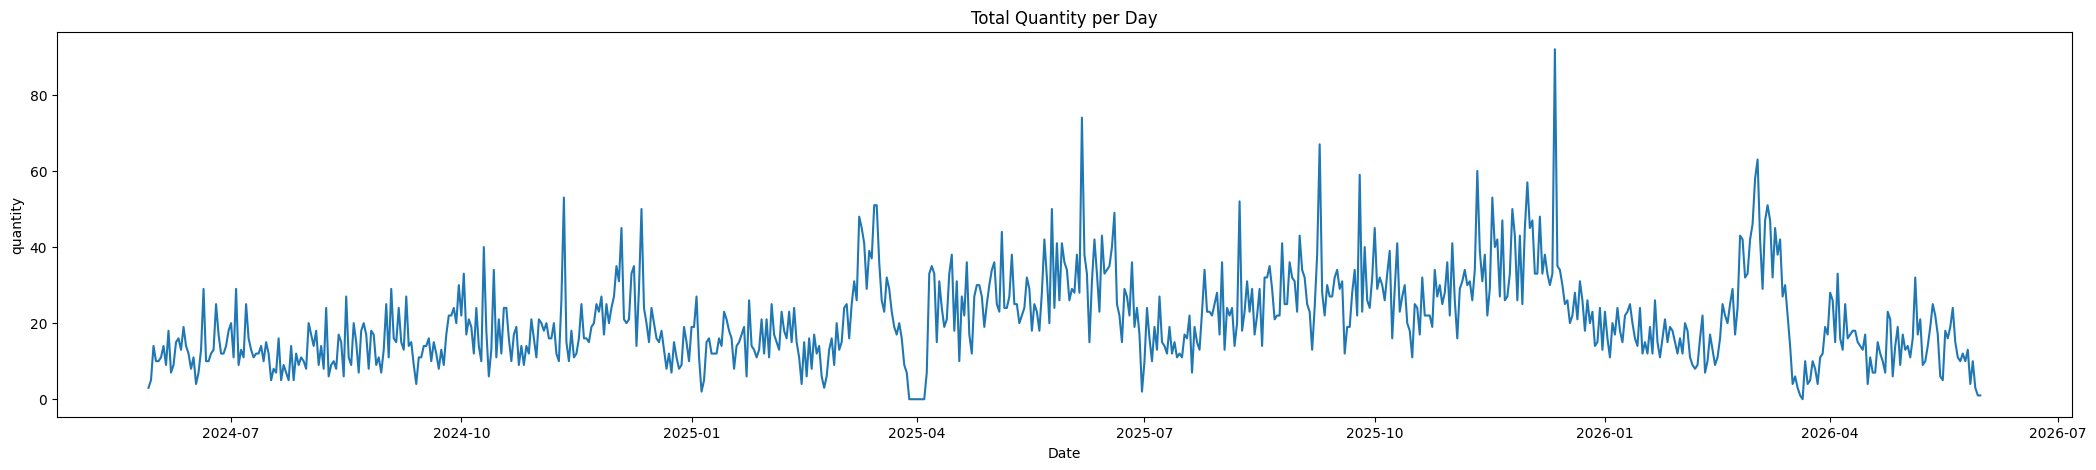

In [495]:
x_axis = df["order_date"]
y_axis = df["quantity"]

plt.figure(figsize=(26, 5))

plt.plot(x_axis, y_axis)

plt.title("Total Quantity per Day")
plt.xlabel("Date")
plt.ylabel("quantity")

plt.show()

count    733.000000
mean      21.009550
std       11.617947
min        0.000000
25%       13.000000
50%       19.000000
75%       27.000000
max       92.000000
Name: quantity, dtype: float64
Skewness: 1.16


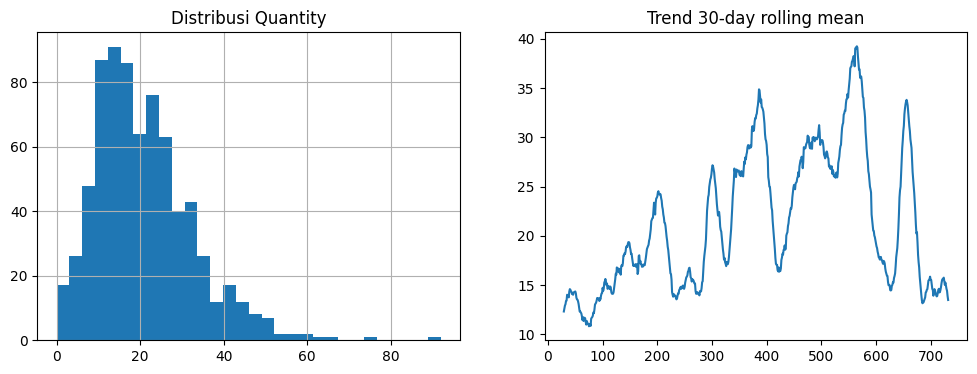

In [496]:
print(df["quantity"].describe())
print(f"Skewness: {df['quantity'].skew():.2f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df["quantity"].hist(bins=30)
plt.title("Distribusi Quantity")

plt.subplot(1, 2, 2)
df["quantity"].rolling(30).mean().plot()
plt.title("Trend 30-day rolling mean")
plt.show()

In [497]:
target = (df["quantity"])
features = df.drop(columns=[
    "order_date", 
    "quantity"
])

split_index = int(len(df) * 0.8)

X_train, X_test = features.iloc[:split_index], features.iloc[split_index:]
y_train, y_test = target.iloc[:split_index], target.iloc[split_index:]

model = lgb.LGBMRegressor(
    n_estimators=500,       # Kita naikkan batasnya karena learning rate diturunkan
    num_leaves=10,          # DITURUNKAN (dari 15) agar pohon tidak terlalu detail menghafal
    max_depth=3,            # DITURUNKAN (dari 4) untuk mencegah overfitting
    min_child_samples=15,   # DINAIKKAN (dari 10) butuh lebih banyak sampel untuk membuat cabang baru
    learning_rate=0.01,     # DITURUNKAN (dari 0.05) agar model belajar pelan-pelan
    subsample=0.7,          # Pakai 70% baris data per pohon
    colsample_bytree=0.7,   # Pakai 70% kolom fitur per pohon
    reg_alpha=1.5,          # L1 Regularization DINAIKKAN drastis
    reg_lambda=1.5,         # L2 Regularization DINAIKKAN drastis
    random_state=42,
)

cat_cols = ["days_name", "month"]

for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)
    X_train[col] = X_train[col].astype("category")
    X_test[col] = pd.Categorical(X_test[col], categories=X_train[col].cat.categories)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test), (X_train, y_train)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=15),
        lgb.log_evaluation(10)
    ]
)

y_pred = model.predict(X_test)


Training until validation scores don't improve for 15 rounds
[10]	training's rmse: 11.0287	training's l2: 121.633	valid_0's rmse: 11.5504	valid_0's l2: 133.412
[20]	training's rmse: 10.5974	training's l2: 112.306	valid_0's rmse: 11.0982	valid_0's l2: 123.171
[30]	training's rmse: 10.2111	training's l2: 104.266	valid_0's rmse: 10.6776	valid_0's l2: 114.012
[40]	training's rmse: 9.88016	training's l2: 97.6175	valid_0's rmse: 10.3089	valid_0's l2: 106.273
[50]	training's rmse: 9.59603	training's l2: 92.0839	valid_0's rmse: 9.99519	valid_0's l2: 99.9039
[60]	training's rmse: 9.35144	training's l2: 87.4494	valid_0's rmse: 9.73668	valid_0's l2: 94.803
[70]	training's rmse: 9.13114	training's l2: 83.3778	valid_0's rmse: 9.49654	valid_0's l2: 90.1842
[80]	training's rmse: 8.94093	training's l2: 79.9403	valid_0's rmse: 9.30153	valid_0's l2: 86.5184
[90]	training's rmse: 8.75436	training's l2: 76.6389	valid_0's rmse: 9.10507	valid_0's l2: 82.9022
[100]	training's rmse: 8.56602	training's l2: 73.

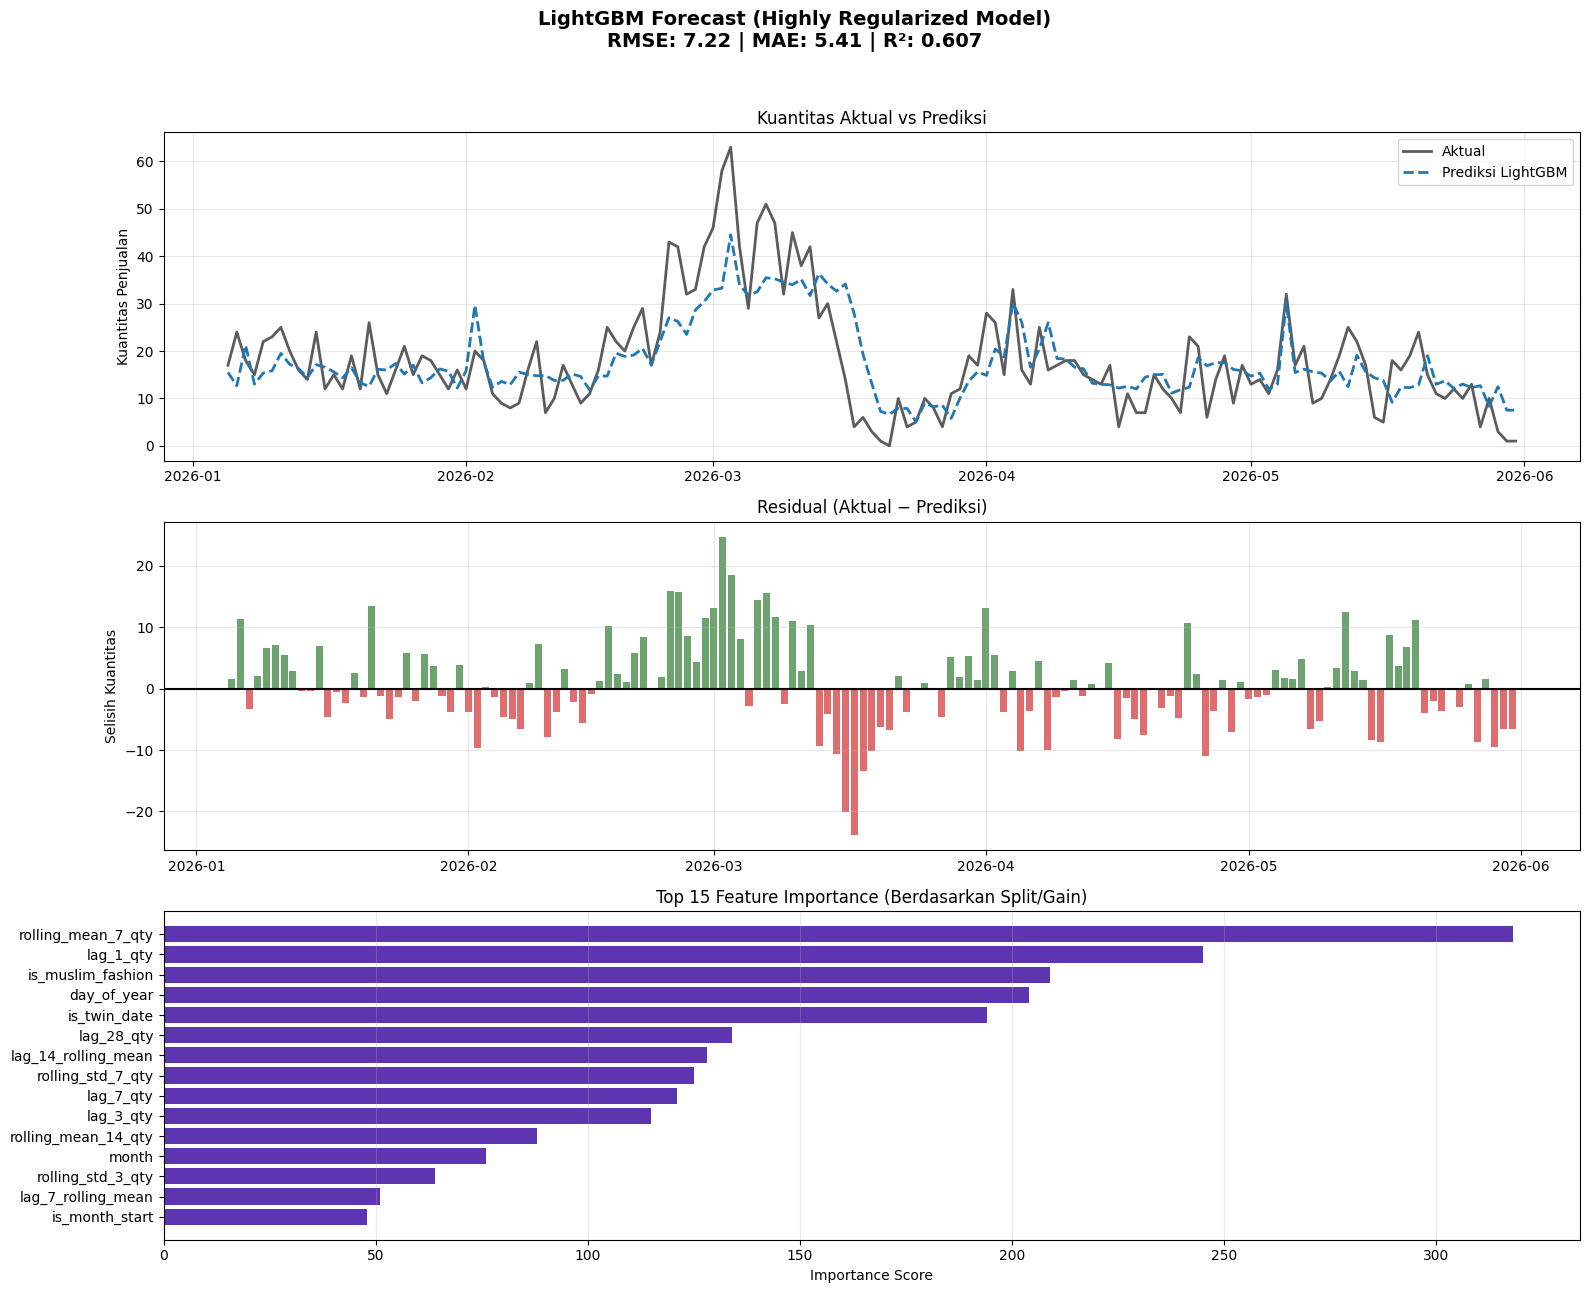

In [498]:
y_pred = np.maximum(model.predict(X_test), 0)

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

test_dates = df["order_date"].iloc[split_index : split_index + len(y_test)].values

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle(f"LightGBM Forecast (Highly Regularized Model)\nRMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.3f}", 
             fontsize=14, fontweight="bold", y=0.92)

axes[0].plot(test_dates, y_test.values, label="Aktual", color="#333333", linewidth=2, alpha=0.8)
axes[0].plot(test_dates, y_pred, label="Prediksi LightGBM", color="#1f77b4", linewidth=2, linestyle="--")
axes[0].set_title("Kuantitas Aktual vs Prediksi", fontsize=12)
axes[0].set_ylabel("Kuantitas Penjualan")
axes[0].legend(loc="upper right", fontsize=10)
axes[0].grid(True, alpha=0.3)

residuals = y_test.values - y_pred
colors = ["#2E7D32" if r >= 0 else "#D32F2F" for r in residuals]

axes[1].bar(test_dates, residuals, color=colors, alpha=0.7, width=0.8)
axes[1].axhline(0, color="black", linewidth=1.5)
axes[1].set_title("Residual (Aktual − Prediksi)", fontsize=12)
axes[1].set_ylabel("Selisih Kuantitas")
axes[1].grid(True, alpha=0.3)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

axes[2].barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#5E35B1")
axes[2].set_title("Top 15 Feature Importance (Berdasarkan Split/Gain)", fontsize=12)
axes[2].set_xlabel("Importance Score")
axes[2].grid(True, alpha=0.3, axis="x")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [499]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Batas Error Prediksi (RMSE): {rmse}")

Batas Error Prediksi (RMSE): 7.2240944497071755


In [500]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Batas Error Prediksi (MAE): {mae}")

Batas Error Prediksi (MAE): 5.408919307732124


In [501]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

R² Score: 0.6066375553231049


In [502]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733 entries, 0 to 732
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   is_muslim_fashion    733 non-null    float64 
 1   days_name            733 non-null    category
 2   month                733 non-null    category
 3   is_weekend           733 non-null    int64   
 4   is_twin_date         733 non-null    int64   
 5   is_payday            733 non-null    int64   
 6   is_ramadhan          733 non-null    int64   
 7   rolling_mean_7_qty   733 non-null    float64 
 8   rolling_mean_14_qty  733 non-null    float64 
 9   rolling_mean_30_qty  733 non-null    float64 
 10  rolling_std_3_qty    733 non-null    float64 
 11  rolling_std_7_qty    733 non-null    float64 
 12  lag_1_qty            733 non-null    float64 
 13  lag_3_qty            733 non-null    float64 
 14  lag_7_qty            733 non-null    float64 
 15  lag_21_qty           73

In [503]:
features.head(20)

,is_muslim_fashion,days_name,month,is_weekend,is_twin_date,is_payday,is_ramadhan,rolling_mean_7_qty,rolling_mean_14_qty,rolling_mean_30_qty,...,lag_21_qty,lag_28_qty,lag_7_rolling_mean,lag_14_rolling_mean,payday_weekend,ramadhan_twin,day_of_year,week_of_year,is_month_end,is_month_start
0,0.0,Wednesday,May,0,0,0,0,5.428571,4.000000,3.607143,...,3.0,2.0,2.571429,3.214286,0,0,150,22,0,0
1,1.0,Thursday,May,0,0,0,0,5.285714,3.785714,3.586207,...,3.0,5.0,2.285714,3.500000,0,0,151,22,0,0
2,0.0,Friday,May,0,0,0,0,5.571429,3.928571,3.633333,...,8.0,7.0,2.285714,3.357143,0,0,152,22,1,0
3,1.0,Saturday,June,1,0,0,0,6.571429,4.785714,4.033333,...,2.0,1.0,3.000000,3.000000,0,0,153,22,0,1
4,1.0,Sunday,June,1,0,0,0,6.571429,5.428571,4.200000,...,5.0,6.0,4.285714,3.000000,0,0,154,22,0,0
5,0.0,Monday,June,0,0,0,0,8.000000,5.857143,4.300000,...,0.0,0.0,3.714286,2.857143,0,0,155,23,0,0
6,1.0,Tuesday,June,0,0,0,0,8.571429,6.500000,4.633333,...,1.0,2.0,4.428571,3.000000,0,0,156,23,0,0
7,0.0,Wednesday,June,0,0,0,0,9.571429,7.500000,4.900000,...,6.0,3.0,5.428571,2.857143,0,0,157,23,0,0
8,0.0,Thursday,June,0,1,0,0,10.428571,7.857143,5.200000,...,3.0,3.0,5.285714,2.928571,0,0,158,23,0,0
9,1.0,Friday,June,0,0,0,0,12.285714,8.928571,5.733333,...,2.0,8.0,5.571429,2.928571,0,0,159,23,0,0


In [506]:
joblib.dump(model, "saved_models/champion_model.pkl")

['saved_models/champion_model.pkl']